In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Grafikler için stil ayarı
sns.set_theme(style="whitegrid")

print("1. Veri RAM'e yükleniyor... (Bu işlem birkaç saniye sürebilir)")
# PyArrow motoru, Parquet dosyalarını okumada standart motora göre çok daha hızlı ve RAM dostudur
df = pd.read_parquet("/content/drive/MyDrive/Data League /veriseti/datathonFINAL.parquet", engine="pyarrow")

# Başlangıçtaki RAM kullanımını ve satır sayısını görelim
print("\n--- Veri Seti Orijinal Boyutu ---")
df.info(memory_usage='deep')



1. Veri RAM'e yükleniyor... (Bu işlem birkaç saniye sürebilir)

--- Veri Seti Orijinal Boyutu ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5004813 entries, 0 to 5004812
Data columns (total 9 columns):
 #   Column            Dtype  
---  ------            -----  
 0   original_text     object 
 1   english_keywords  object 
 2   sentiment         float64
 3   main_emotion      object 
 4   primary_theme     object 
 5   language          object 
 6   url               object 
 7   author_hash       object 
 8   date              object 
dtypes: float64(1), object(8)
memory usage: 3.9 GB


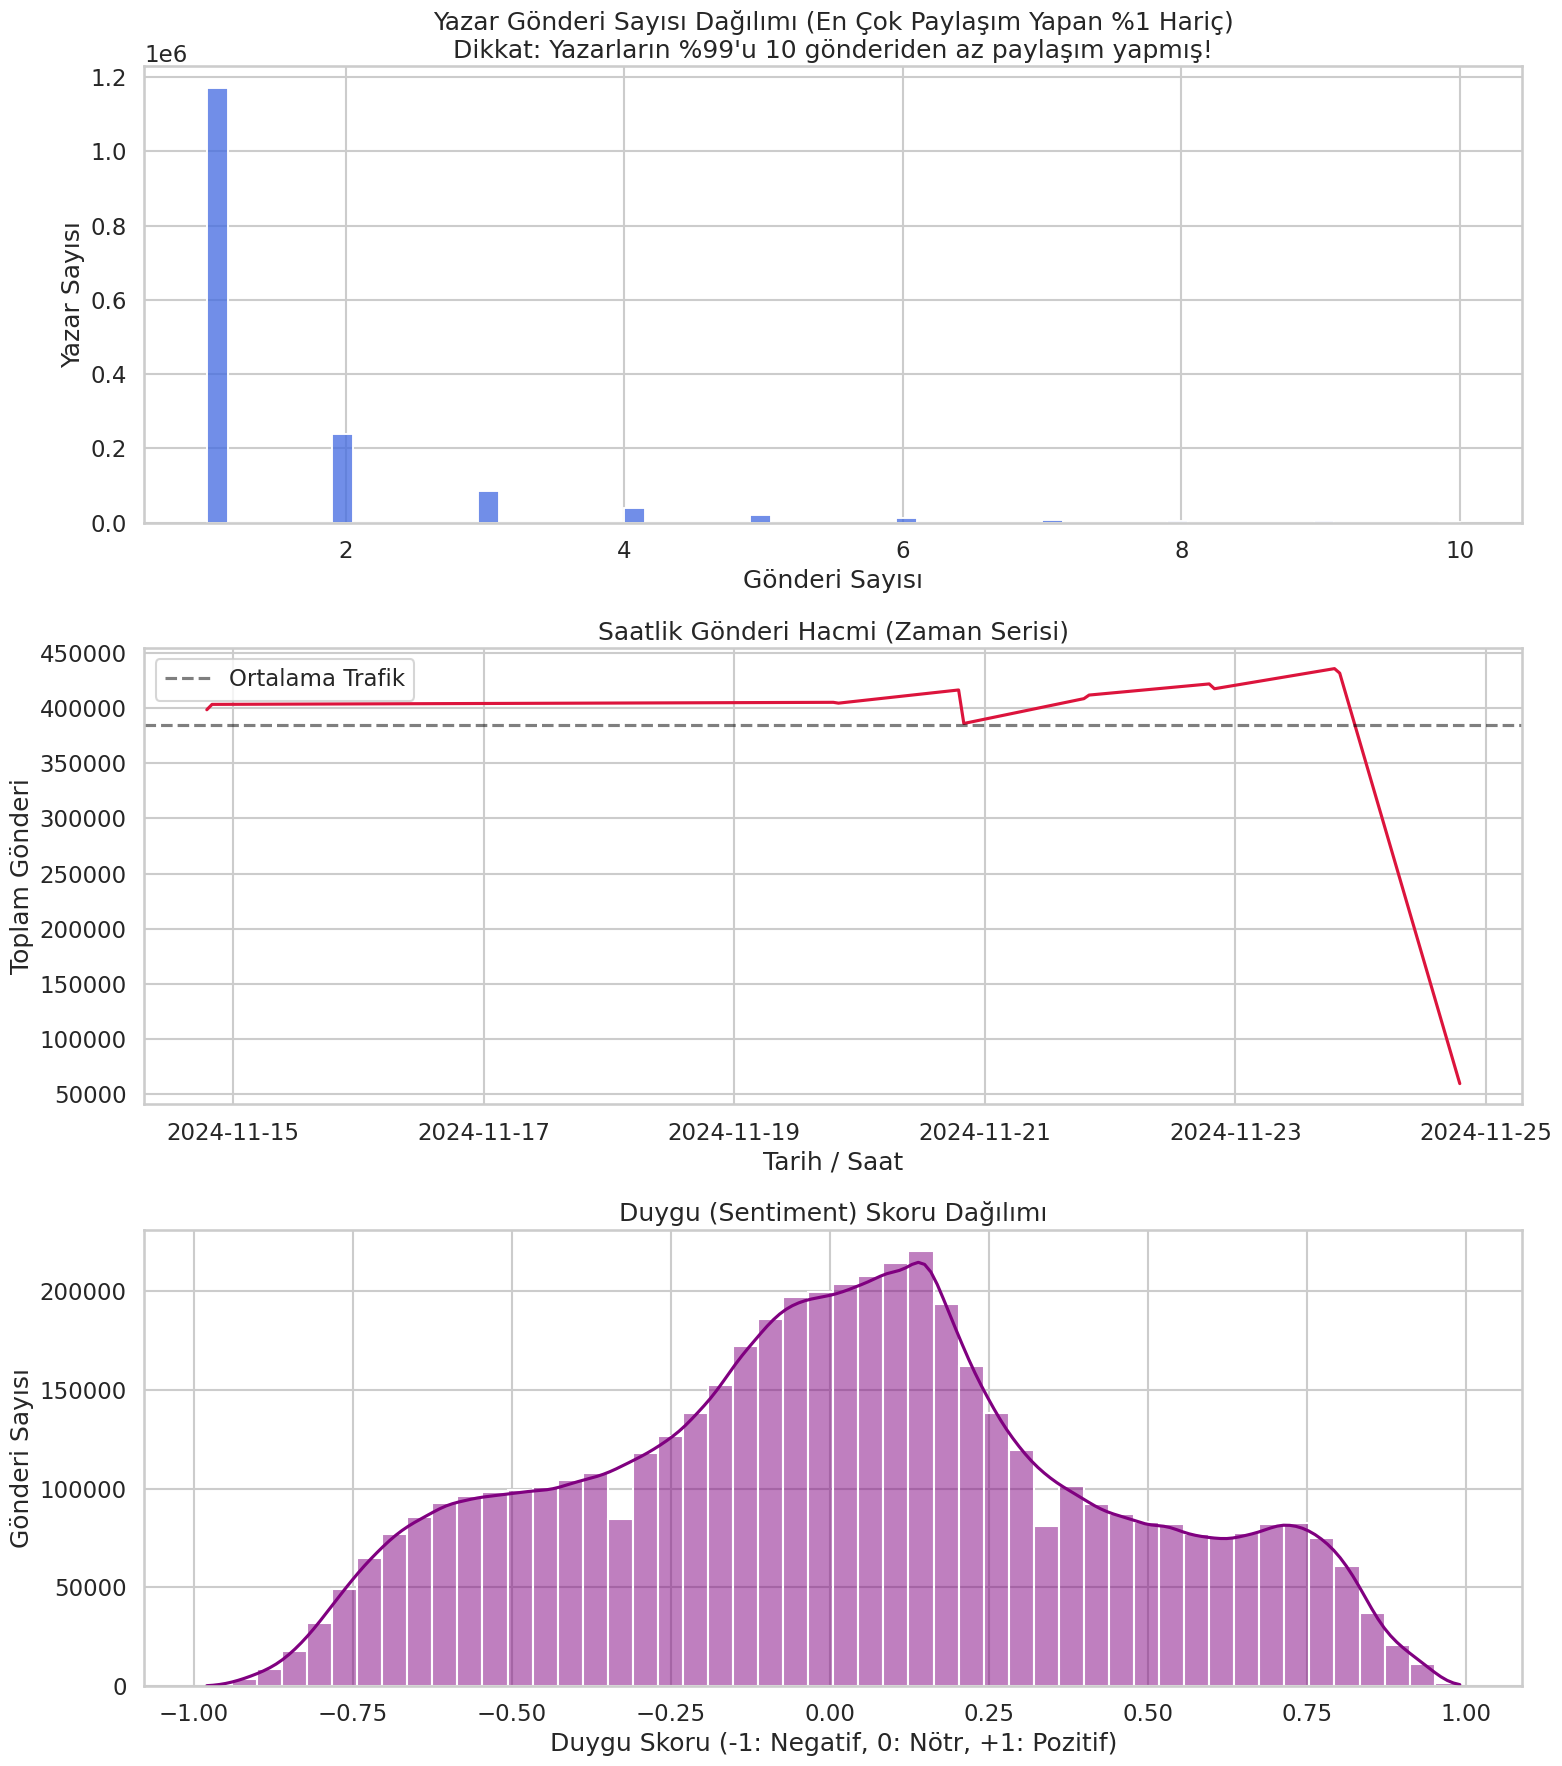

--- EDA KISA ÖZETİ ---
Toplam Yazar Sayısı: 1,597,838
Ortalama Gönderi/Yazar: 3.1
Maksimum Gönderi (En Aktif Hesap): 2,147,605
Saatlik Ortalama Trafik: 384986 Gönderi/Saat


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Grafikler için genel estetik ayarları
sns.set_theme(style="whitegrid", context="talk")

# 3 satırlık bir grafik paneli oluşturuyoruz
fig, axes = plt.subplots(3, 1, figsize=(16, 18))

# ---------------------------------------------------------
# 1. AKTİVİTE DAĞILIMI: İnsanlar vs Hiper-Aktif Hesaplar
# ---------------------------------------------------------
# Her yazarın kaç gönderi attığını hesapla
author_counts = df['author_hash'].value_counts()

# Sadece kuyruğu ezmemek için en çok atan %1'lik dilimi (outliers) görelim
percentile_99 = author_counts.quantile(0.99)
sns.histplot(author_counts[author_counts <= percentile_99],
             bins=60, color="royalblue", ax=axes[0])

axes[0].set_title(f"Yazar Gönderi Sayısı Dağılımı (En Çok Paylaşım Yapan %1 Hariç)\nDikkat: Yazarların %99'u {int(percentile_99)} gönderiden az paylaşım yapmış!")
axes[0].set_xlabel("Gönderi Sayısı")
axes[0].set_ylabel("Yazar Sayısı")

# ---------------------------------------------------------
# 2. ZAMAN SERİSİ: Organik Trafik vs Organize Saldırı
# ---------------------------------------------------------
# HATA ÇÖZÜMÜ: 'date' sütununun kesinlikle datetime formatında olduğundan emin oluyoruz.
# Eğer zaten datetime ise bu satır hiçbir şeyi bozmaz, güvenlidir.
df['date'] = pd.to_datetime(df['date'], utc=True)

# Şimdi gönül rahatlığıyla saat bazında yuvarlama (.dt.floor) yapabiliriz
hourly_traffic = df.groupby(df['date'].dt.floor('h')).size()

sns.lineplot(x=hourly_traffic.index, y=hourly_traffic.values, color="crimson", ax=axes[1])
axes[1].set_title("Saatlik Gönderi Hacmi (Zaman Serisi)")
axes[1].set_xlabel("Tarih / Saat")
axes[1].set_ylabel("Toplam Gönderi")

# Ortalama trafiği gösteren bir çizgi çekelim
axes[1].axhline(hourly_traffic.mean(), color='black', linestyle='--', alpha=0.5, label='Ortalama Trafik')
axes[1].legend()

# ---------------------------------------------------------
# 3. DUYGU (SENTIMENT) KUTUPLAŞMASI: Botlar Uçlarda mı Geziyor?
# ---------------------------------------------------------
# Sentiment skorlarının dağılımı (-1.0 ile +1.0 arası)
sns.histplot(df['sentiment'], bins=50, color="purple", kde=True, ax=axes[2])
axes[2].set_title("Duygu (Sentiment) Skoru Dağılımı")
axes[2].set_xlabel("Duygu Skoru (-1: Negatif, 0: Nötr, +1: Pozitif)")
axes[2].set_ylabel("Gönderi Sayısı")

plt.tight_layout()
plt.show()

# --- ÖZET İSTATİSTİKLER ---
print("--- EDA KISA ÖZETİ ---")
print(f"Toplam Yazar Sayısı: {len(author_counts):,}")
print(f"Ortalama Gönderi/Yazar: {author_counts.mean():.1f}")
print(f"Maksimum Gönderi (En Aktif Hesap): {author_counts.max():,}")
print(f"Saatlik Ortalama Trafik: {hourly_traffic.mean():.0f} Gönderi/Saat")

In [ ]:
import pandas as pd
import numpy as np

print("1. Veriler zaman sırasına diziliyor (Temporal analiz için kritik)...")
# Aynı yazarın gönderilerini zaman sırasına sokuyoruz
df.sort_values(by=['author_hash', 'date'], inplace=True)

# İki gönderi arasındaki saniye farkını hesaplıyoruz (Inter-arrival time)
df['time_diff_sec'] = df.groupby('author_hash')['date'].diff().dt.total_seconds()

print("2. Kullanıcı Davranış Matrisi (Feature Matrix) inşa ediliyor...")

# Her bir yazar için istatistiksel özellikleri (Feature'ları) hesaplıyoruz
user_profiles = df.groupby('author_hash').agg(

    # --- 1. HACİM VE HİPER-AKTİVİTE ÖZELLİKLERİ ---
    # EDA'da gördüğümüz %99'luk 10 gönderi sınırını yakalamak için
    post_count=('original_text', 'count'),

    # --- 2. KOORDİNASYON VE ÇEŞİTLİLİK (SOTA) ---
    # Gerçek insanlar tek platform ve birkaç dilde konuşur. Çapraz platform botlarını bulmak için:
    unique_platforms=('url', 'nunique'),
    unique_languages=('language', 'nunique'),
    unique_themes=('primary_theme', 'nunique'),

    # --- 3. ZAMANSAL MEKANİKLİK (EN GÜÇLÜ BOT YAKALAYICI) ---
    # O dümdüz kırmızı çizgiyi yaratan botları bu özellikle avlayacağız.
    # Botların gönderi aralıkları (örneğin hep 60 saniye) sabittir, standart sapması (std) 0'a yakındır.
    time_diff_mean=('time_diff_sec', 'mean'),
    time_diff_std=('time_diff_sec', 'std'),
    time_diff_min=('time_diff_sec', 'min'), # İnsanüstü hızlar (0 saniye)

    # --- 4. DUYGU KUTUPLAŞMASI (SENTIMENT POLARIZATION) ---
    # Hep aynı duygu skorunu (örneğin sürekli -0.8) basan hesaplar için
    sentiment_mean=('sentiment', 'mean'),
    sentiment_std=('sentiment', 'std'),
    emotion_diversity=('main_emotion', 'nunique')
).reset_index()

print("3. Eksik Değerler ve Anormal Sayılar Temizleniyor...")

# Sadece 1 gönderisi olan gerçek insanların zaman farkı standart sapması (std) hesaplanamaz (NaN döner).
# Modeli bozmaması için bu NaN değerleri güvenli bir "insan" değeriyle (örneğin -1) dolduruyoruz.
user_profiles['time_diff_std'] = user_profiles['time_diff_std'].fillna(-1)
user_profiles['time_diff_mean'] = user_profiles['time_diff_mean'].fillna(-1)
user_profiles['sentiment_std'] = user_profiles['sentiment_std'].fillna(0)

# 4. YENİ ÖZELLİKLER (TÜRETİLMİŞ/DERIVED FEATURES)
# SOTA çalışmalarında "Hız" çok önemlidir.
user_profiles['posts_per_platform'] = user_profiles['post_count'] / user_profiles['unique_platforms']

# %99'luk sınırımızdan ilham alan "Hiper-Aktiflik" Flag'i (1 veya 0)
user_profiles['is_hyperactive'] = (user_profiles['post_count'] > 10).astype(int)

print(f"\nFeature Engineering Tamamlandı! Oluşturulan Matris Boyutu: {user_profiles.shape}")
print(user_profiles.head())

1. Veriler zaman sırasına diziliyor (Temporal analiz için kritik)...
2. Kullanıcı Davranış Matrisi (Feature Matrix) inşa ediliyor...
3. Eksik Değerler ve Anormal Sayılar Temizleniyor...

Feature Engineering Tamamlandı! Oluşturulan Matris Boyutu: (1597838, 13)
                                author_hash  post_count  unique_platforms  \
0                                               2147605              1207   
1  0000071a2918d838352862180b3f47e1ed53c332           2                 1   
2  00001b81dde185e114611d47298c2d7687e0b3ca           1                 1   
3  000029fda00230cf218ee77deaeda5fbed6d5078           1                 1   
4  00002ca22b693dab7a87d949a96cde8fd51a3af5           1                 1   

   unique_languages  unique_themes  time_diff_mean  time_diff_std  \
0               111             16        0.402603     314.055241   
1                 1              2      134.000000      -1.000000   
2                 1              1       -1.000000      -1.000000   
3

In [ ]:
import pandas as pd
import numpy as np

# 1. KESİN AYRIM: Kimliği olanlar ve olmayanları (boşluk karakteri dahil) güvenli bir şekilde ayırıyoruz.
# strip() metodu ile sadece boşluklardan oluşan (örn: "   ") satırları da yakalıyoruz.
is_anonymous = df['author_hash'].astype(str).str.strip() == ""

df_known = df[~is_anonymous].copy()
df_anon = df[is_anonymous].copy()

print(f"Kimliği Belirli Gönderiler: {len(df_known):,}")
print(f"Anonim (Karanlık) Gönderiler: {len(df_anon):,}")

# ---------------------------------------------------------
# ANONİM VERİLER İÇİN KAMPANYA MATRİSİ (Campaign Matrix)
# ---------------------------------------------------------
print("\nAnonim veriler için 10 Dakikalık Kampanya Matrisi oluşturuluyor...")

# Her bir gönderiyi 10 dakikalık pencerelere (time windows) yuvarlıyoruz
df_anon['time_window'] = df_anon['date'].dt.floor('10min')

# Yazar bazında değil, "Zaman + Platform + Dil" kırılımında grupluyoruz
campaign_matrix = df_anon.groupby(['time_window', 'url', 'language']).agg(

    # O 10 dakikalık penceredeki hacim
    post_count=('original_text', 'count'),

    # Tema tek bir noktaya mı odaklanmış? (Sıfıra yakınsa manipülasyondur)
    unique_themes=('primary_theme', 'nunique'),

    # Duygu durumu nasıl? (Örn: Sadece öfke basılıyorsa)
    sentiment_mean=('sentiment', 'mean'),
    sentiment_std=('sentiment', 'std'),

    # Kopyala-yapıştır metinler var mı?
    # (Benzersiz metin sayısı toplam metin sayısına çok düşükse bot saldırısıdır)
    unique_texts=('original_text', 'nunique')
).reset_index()

# Kopya Oranı (Duplication Rate) Özelliği - SOTA için çok kritiktir
# 1.0 = Her metin farklı (İnsan) | 0.0'a yakın = Hepsi kopyala yapıştır (Bot)
campaign_matrix['text_uniqueness_ratio'] = campaign_matrix['unique_texts'] / campaign_matrix['post_count']

# Sadece anlamlı kampanyaları (10 dakikada en az 5 gönderi olanları) filtreleyelim
campaign_matrix = campaign_matrix[campaign_matrix['post_count'] > 5]

print("\n--- Tespit Edilen En Büyük Anonim Kampanyalar (Saldırılar) ---")
print(campaign_matrix.sort_values(by='post_count', ascending=False).head())

Kimliği Belirli Gönderiler: 2,857,208
Anonim (Karanlık) Gönderiler: 2,147,605

Anonim veriler için 10 Dakikalık Kampanya Matrisi oluşturuluyor...

--- Tespit Edilen En Büyük Anonim Kampanyalar (Saldırılar) ---
                    time_window             url language  post_count  \
1615  2024-11-14 19:50:00+00:00  www.reddit.com       en       18826   
1934  2024-11-14 20:00:00+00:00  www.reddit.com       en       17953   
2537  2024-11-14 20:20:00+00:00  www.reddit.com       en       17917   
12005 2024-11-23 19:20:00+00:00  www.reddit.com       en       17779   
11812 2024-11-23 19:10:00+00:00  www.reddit.com       en       17721   

       unique_themes  sentiment_mean  sentiment_std  unique_texts  \
1615              15       -0.006734       0.401175         18698   
1934              15       -0.006425       0.401046         17801   
2537              15       -0.004939       0.397236         17794   
12005             15        0.037702       0.402020         17583   
11812       

In [ ]:
import pandas as pd

# Her yazarın kullandığı tüm anahtar kelimeleri birleştirip tekil (unique) kelime sayısını bulalım
keyword_features = df.groupby('author_hash').agg(
    total_keywords=('english_keywords', lambda x: len(','.join(x.dropna()).split(','))),
    unique_keywords=('english_keywords', lambda x: len(set(','.join(x.dropna()).split(','))))
).reset_index()

# Kelime Çeşitlilik Oranı (Lexical Diversity)
# 1.0'a yakınsa zengin bir dili var (İnsan), 0.0'a yakınsa hep aynı kelimeleri basıyor (Bot)
keyword_features['lexical_diversity'] = keyword_features['unique_keywords'] / (keyword_features['total_keywords'] + 1)

# Bu hızlı NLP özelliklerini önceki user_profiles matrisimize birleştirebiliriz
user_profiles = pd.merge(user_profiles, keyword_features, on='author_hash', how='left')

In [ ]:
import pandas as pd
import numpy as np
import torch
from sentence_transformers import CrossEncoder

# 1. GPU KONTROLÜ
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Kullanılan İşlemci: {device.upper()}")
if device == 'cpu':
    print("UYARI: GPU aktif değil! Lütfen Colab ayarlarından T4 GPU'yu seçin.")

# 2. MODELİ GPU'YA YÜKLEME
print("Model GPU belleğine yükleniyor...")
# device=device parametresi modelin doğrudan VRAM'e (Ekran Kartı Belleği) inmesini sağlar
encoder_model = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', device=device)

# --- (Verini 'df_suspicious' olarak filtrelediğini varsayıyoruz) ---
# Örn: df_suspicious = df[df['author_hash'].isin(suspicious_authors)]

print("3. GPU için Veri Yığınları (Batches) Hazırlanıyor...")
all_pairs = []
pair_authors = []

# --- UYGULAMA ---
# Zaman kazanmak için SADECE şüpheli/hiper-aktif hesapları filtreleyelim
suspicious_authors = user_profiles[user_profiles['is_hyperactive'] == 1]['author_hash']
df_suspicious = df[df['author_hash'].isin(suspicious_authors)]

# Sadece metin çifti oluşturabilecek (en az 2 gönderisi olan) hesapları alıyoruz
for author, group in df_suspicious.groupby('author_hash'):
    texts = group['original_text'].dropna().tolist()
    if len(texts) >= 2:
        # Ardışık tweetleri [Tweet 1, Tweet 2] şeklinde çiftliyoruz
        for i in range(len(texts)-1):
            all_pairs.append([texts[i], texts[i+1]])
            pair_authors.append(author)

print(f"Toplam {len(all_pairs):,} adet ardışık metin çifti oluşturuldu.")

# 4. GPU ÜZERİNDE TOPLU İŞLEME (ASIL SİHİR BURADA)
print("4. GPU üzerinden Cross-Encoder tahminleri yapılıyor... (Arkana yaslan)")
# batch_size=256: Ekran kartına tek seferde 256 çift yollar.
# Eğer Colab 'Out of Memory (OOM)' hatası verirse bunu 128'e veya 64'e düşür.
raw_scores = encoder_model.predict(all_pairs, batch_size=256, show_progress_bar=True)

# 5. SKORLARI YAZARLARA GERİ DAĞITMA
print("5. Skorlar yazarlara göre gruplanıp ortalamaları alınıyor...")
# Tahmin sonuçlarını yazarlarla eşleştiren geçici bir veri çerçevesi oluşturuyoruz
scores_df = pd.DataFrame({
    'author_hash': pair_authors,
    'pair_score': raw_scores
})

# Her yazar için kendi içindeki benzerliklerin (self-similarity) ortalamasını alıyoruz
semantic_scores = scores_df.groupby('author_hash').agg(
    semantic_rigidity=('pair_score', 'mean')
).reset_index()

print("\nİşlem Tamam! Örnek Çıktı:")
print(semantic_scores.head())

Kullanılan İşlemci: CUDA
Model GPU belleğine yükleniyor...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


3. GPU için Veri Yığınları (Batches) Hazırlanıyor...
Toplam 2,603,177 adet ardışık metin çifti oluşturuldu.
4. GPU üzerinden Cross-Encoder tahminleri yapılıyor... (Arkana yaslan)


Batches:   0%|          | 0/10169 [00:00<?, ?it/s]

5. Skorlar yazarlara göre gruplanıp ortalamaları alınıyor...

İşlem Tamam! Örnek Çıktı:
                                author_hash  semantic_rigidity
0                                                   -10.141002
1  000184c118a242e0f00bab9afceec1d635d65ae0         -10.511220
2  000b094a75cf8a6c6426f5318baba43c5baf0285           7.006527
3  000e793db70c59309fa6f0f36d0046d110f3be3c         -10.867693
4  0012f1a7368eca1d8981ceda52e06ebf2e24891f         -10.063437


In [ ]:
# Elde edilen "anlamsal donukluk" (semantic_rigidity) skorunu ana matrisimize ekleyelim
user_profiles = pd.merge(user_profiles, semantic_scores, on='author_hash', how='left')

# Normal hesaplar için bu skoru güvenli bir değer (örneğin -999) ile dolduralım
user_profiles['semantic_rigidity'].fillna(-999, inplace=True)

/tmp/ipykernel_2354/92039235.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  user_profiles['semantic_rigidity'].fillna(-999, inplace=True)


In [ ]:
# 'semantic_rigidity' sütunundaki tüm -999 değerlerini -1 ile değiştiriyoruz
user_profiles['semantic_rigidity'] = user_profiles['semantic_rigidity'].replace(-999, -1)

In [ ]:
import pandas as pd
import numpy as np

print("Yeni bağlamlar (Contextual Features) çıkarılıyor...")

# 1. Metin Uzunlukları ve Kelime Sayıları (Satır bazlı işlemler)
# Orijinal metnin karakter uzunluğu
df_known['text_length'] = df_known['original_text'].astype(str).str.len()

# İngilizce anahtar kelime sayısını bulma (virgülleri sayarak)
# Eğer null ise 0 döndürür
df_known['keyword_count'] = df_known['english_keywords'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) and str(x).strip() != "" else 0
)

# Saati (0-23) bulma (Uyku döngüsü için)
df_known['hour_of_day'] = df_known['date'].dt.hour

print("Yazar bazında özetlemeler yapılıyor...")

# 2. Yazarlara (Author_hash) göre gruplayıp yeni özellikleri (Feature) oluşturma
context_features = df_known.groupby('author_hash').agg(

    # --- YAPISAL ÖZELLİKLER ---
    # Şablon botları bulmak için uzunluk standart sapması
    text_length_mean=('text_length', 'mean'),
    text_length_std=('text_length', 'std'),

    # --- ÇAPRAZ DİL (KULLANICININ YAKALADIĞI FİKİR) ---
    # Ortalama kaç keyword kullanıyor?
    avg_keywords_per_post=('keyword_count', 'mean'),

    # --- BİYOLOJİK RİTİM (UYKU DÖNGÜSÜ) ---
    # Günün 24 saatinin kaçında aktif? (Maksimum 24 olabilir)
    unique_active_hours=('hour_of_day', 'nunique')
).reset_index()

# 1 gönderisi olanlarda std NaN olur, sıfırla dolduruyoruz
context_features['text_length_std'] = context_features['text_length_std'].fillna(0)

# 3. Türetilmiş (Derived) Özellik: SPAM İNDEKSİ
# Eğer metin kısa ama anahtar kelime çoksa (örn: 20 karakterlik metinde 5 keyword), bu SEO spamıdır.
# +1 ekleyerek sıfıra bölünme hatasını engelliyoruz
context_features['keyword_stuffing_index'] = context_features['avg_keywords_per_post'] / (context_features['text_length_mean'] / 10 + 1)

print("Ana matris ile birleştiriliyor...")
# Bu yeni özellikleri önceki aşamalarda oluşturduğumuz 'user_profiles' matrisine birleştiriyoruz
user_profiles = pd.merge(user_profiles, context_features, on='author_hash', how='left')

print("\n--- Son Durum: Zenginleştirilmiş Kullanıcı Matrisi ---")
print(user_profiles[['author_hash', 'text_length_std', 'unique_active_hours', 'keyword_stuffing_index']].head())

Yeni bağlamlar (Contextual Features) çıkarılıyor...
Yazar bazında özetlemeler yapılıyor...
Ana matris ile birleştiriliyor...

--- Son Durum: Zenginleştirilmiş Kullanıcı Matrisi ---
                                author_hash  text_length_std  \
0                                                        NaN   
1  0000071a2918d838352862180b3f47e1ed53c332        38.890873   
2  00001b81dde185e114611d47298c2d7687e0b3ca         0.000000   
3  000029fda00230cf218ee77deaeda5fbed6d5078         0.000000   
4  00002ca22b693dab7a87d949a96cde8fd51a3af5         0.000000   

   unique_active_hours  keyword_stuffing_index  
0                  NaN                     NaN  
1                  1.0                0.855148  
2                  1.0                1.052632  
3                  1.0                0.769231  
4                  1.0                1.983471  


In [ ]:
import pandas as pd

# 1. Adım: Kimlikli veriyi (df_known) kampanya matrisi ile birleştirme
df_known['time_window'] = df_known['date'].dt.floor('10min')

# ÇÖZÜM: Kampanya matrisinden alacağımız sütunların isimlerini baştan değiştiriyoruz ki karmaşa olmasın
campaign_subset = campaign_matrix[['time_window', 'url', 'language', 'text_uniqueness_ratio', 'post_count']].copy()
campaign_subset.rename(columns={
    'post_count': 'campaign_post_count',
    'text_uniqueness_ratio': 'campaign_uniqueness'
}, inplace=True)

# Artık suffixes parametresine ihtiyaç duymadan, tertemiz bir merge yapabiliriz
df_with_campaigns = pd.merge(
    df_known,
    campaign_subset,
    on=['time_window', 'url', 'language'],
    how='left'
)

# Yazar bazında özetleyelim
print("Kampanya özellikleri yazarlara aktarılıyor...")
campaign_features = df_with_campaigns.groupby('author_hash').agg(
    avg_campaign_uniqueness=('campaign_uniqueness', 'mean'),
    participation_in_bursts=('campaign_post_count', 'count')
).reset_index()

# KRİTİK: Hiçbir manipülatif kampanyaya denk gelmemiş temiz insanların verisi NaN olacaktır.
# Bu kişilerin katılımını 0, benzersizlik oranını 1.0 (en temiz) olarak dolduruyoruz.
campaign_features.fillna({
    'avg_campaign_uniqueness': 1.0,
    'participation_in_bursts': 0
}, inplace=True)

# user_profiles tablosu ile birleştirme
# Eğer önceden eklediysen hata vermemesi için önce eski sütunları atalım (opsiyonel)
cols_to_use = campaign_features.columns.difference(user_profiles.columns).tolist() + ['author_hash']
user_profiles = pd.merge(user_profiles, campaign_features[cols_to_use], on='author_hash', how='left')

print("Kampanya Entegrasyonu Başarılı!")
print(user_profiles[['author_hash', 'avg_campaign_uniqueness', 'participation_in_bursts']].head())

Kampanya özellikleri yazarlara aktarılıyor...
Kampanya Entegrasyonu Başarılı!
                                author_hash  avg_campaign_uniqueness  \
0                                                                NaN   
1  0000071a2918d838352862180b3f47e1ed53c332                 0.988868   
2  00001b81dde185e114611d47298c2d7687e0b3ca                 1.000000   
3  000029fda00230cf218ee77deaeda5fbed6d5078                 1.000000   
4  00002ca22b693dab7a87d949a96cde8fd51a3af5                 1.000000   

   participation_in_bursts  
0                      NaN  
1                      2.0  
2                      0.0  
3                      0.0  
4                      1.0  


In [ ]:
# 2. Adım: Eşgüdümlü Davranış (Co-occurrence) Özelliği
# Aynı anda, aynı platformda, aynı temada kaç farklı kullanıcı aktif?
burst_activity = df_known.groupby(['time_window', 'url', 'primary_theme']).agg(
    total_users_in_burst=('author_hash', 'nunique')
).reset_index()

# Bu bilgiyi tekrar ana veriye bağlayıp kullanıcı bazında özetliyoruz
df_burst = pd.merge(df_known, burst_activity, on=['time_window', 'url', 'primary_theme'])

graph_features = df_burst.groupby('author_hash').agg(
    max_co_occurrence=('total_users_in_burst', 'max'), # En kalabalık 'şüpheli grupta' kaç kişi vardı?
    avg_co_occurrence=('total_users_in_burst', 'mean')
).reset_index()

user_profiles = pd.merge(user_profiles, graph_features, on='author_hash', how='left')

In [65]:
user_profiles.info()
display(user_profiles.head())
campaign_matrix.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1597838 entries, 0 to 1597837
Data columns (total 35 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   author_hash              1597838 non-null  object 
 1   post_count               1597838 non-null  int64  
 2   unique_platforms         1597838 non-null  int64  
 3   unique_languages         1597838 non-null  int64  
 4   unique_themes            1597838 non-null  int64  
 5   time_diff_mean           1597838 non-null  float64
 6   time_diff_std            1597838 non-null  float64
 7   time_diff_min            426904 non-null   float64
 8   sentiment_mean           1597838 non-null  float64
 9   sentiment_std            1597838 non-null  float64
 10  emotion_diversity        1597838 non-null  int64  
 11  posts_per_platform       1597838 non-null  float64
 12  is_hyperactive           1597838 non-null  int64  
 13  total_keywords           1597838 non-null 

,author_hash,post_count,unique_platforms,unique_languages,unique_themes,time_diff_mean,time_diff_std,time_diff_min,sentiment_mean,sentiment_std,...,avg_co_occurrence,organicity_score,label,is_manipulative,lgbm_bot_probability,final_organic_score,if_score,lgbm_bot_prob,pseudo_label_lgbm,lgbm_manipulative_prob
0,,2147605,1207,111,16,0.402603,314.055241,0.0,0.007318,0.402011,...,NaN,0.055563,-1,1,9.999998e-01,0.031946,-0.216789,9.999998e-01,1.0,0.968054
1,0000071a2918d838352862180b3f47e1ed53c332,2,1,1,2,134.000000,-1.000000,134.0,0.300000,0.141421,...,550.5,0.839305,1,0,9.089843e-07,0.024727,0.154606,9.999998e-01,NaN,0.975273
2,00001b81dde185e114611d47298c2d7687e0b3ca,1,1,1,1,-1.000000,-1.000000,NaN,0.090000,0.000000,...,3099.0,0.926232,1,0,6.903824e-07,0.965435,0.195798,1.514778e-07,NaN,0.034565
3,000029fda00230cf218ee77deaeda5fbed6d5078,1,1,1,1,-1.000000,-1.000000,NaN,0.180000,0.000000,...,640.0,0.967367,1,0,3.039292e-07,0.965435,0.215291,1.514778e-07,NaN,0.034565
4,00002ca22b693dab7a87d949a96cde8fd51a3af5,1,1,1,1,-1.000000,-1.000000,NaN,-0.010000,0.000000,...,897.0,0.917596,1,0,1.453630e-06,0.865019,0.191705,4.448150e-06,NaN,0.134981


<class 'pandas.core.frame.DataFrame'>
Index: 4045 entries, 30 to 13850
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   time_window            4045 non-null   datetime64[ns, UTC]
 1   url                    4045 non-null   object             
 2   language               4045 non-null   object             
 3   post_count             4045 non-null   int64              
 4   unique_themes          4045 non-null   int64              
 5   sentiment_mean         4045 non-null   float64            
 6   sentiment_std          4045 non-null   float64            
 7   unique_texts           4045 non-null   int64              
 8   text_uniqueness_ratio  4045 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(3), int64(3), object(2)
memory usage: 316.0+ KB


In [ ]:
user_profiles.tail()


,author_hash,post_count,unique_platforms,unique_languages,unique_themes,time_diff_mean,time_diff_std,time_diff_min,sentiment_mean,sentiment_std,...,is_hyperactive,total_keywords,unique_keywords,lexical_diversity,text_length_mean,text_length_std,avg_keywords_per_post,unique_active_hours,keyword_stuffing_index,semantic_rigidity
1597833,ffffe5cd25f85fc141dc06333d5237308db06814,1,1,1,1,-1.0,-1.0,NaN,0.190,0.000000,...,0,7,7,0.875000,23.0,0.000000,7.0,1.0,2.121212,-1.0
1597834,ffffeac5675959eb78fac8443dcdddf0a04cbb48,2,1,1,2,35.0,-1.0,35.0,0.455,0.063640,...,0,20,20,0.952381,76.5,6.363961,10.0,1.0,1.156069,-1.0
1597835,ffffefd4a4a23849b5ce36ae64a9f3a9cc0f8a2e,1,1,1,1,-1.0,-1.0,NaN,0.190,0.000000,...,0,1,1,0.500000,9.0,0.000000,1.0,1.0,0.526316,-1.0
1597836,fffff8e0521ab8a8df6a19b47eb87edf1fc71bff,1,1,1,1,-1.0,-1.0,NaN,0.770,0.000000,...,0,25,25,0.961538,336.0,0.000000,25.0,1.0,0.722543,-1.0
1597837,fffffaa5ad1767beefc64e2e7ee8916deb171d4a,2,1,1,2,256925.0,-1.0,256925.0,0.180,0.438406,...,0,61,61,0.983871,281.5,19.091883,30.5,1.0,1.046312,-1.0


/tmp/ipykernel_5298/1918567382.py:2: DeprecationWarning: `count` was renamed; use `len` instead
  lang_dist = df_lazy.group_by("language").count().sort("count", descending=True).collect()
/tmp/ipykernel_5298/1918567382.py:3: DeprecationWarning: `count` was renamed; use `len` instead
  url_dist = df_lazy.group_by("url").count().sort("count", descending=True).collect()
/tmp/ipykernel_5298/1918567382.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lang_dist.head(10).to_pandas(), x="count", y="language", ax=axes[0], palette="viridis")
/tmp/ipykernel_5298/1918567382.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=url_dist.head(10).to_pandas(), x="count", y="url", ax=axes[1], 

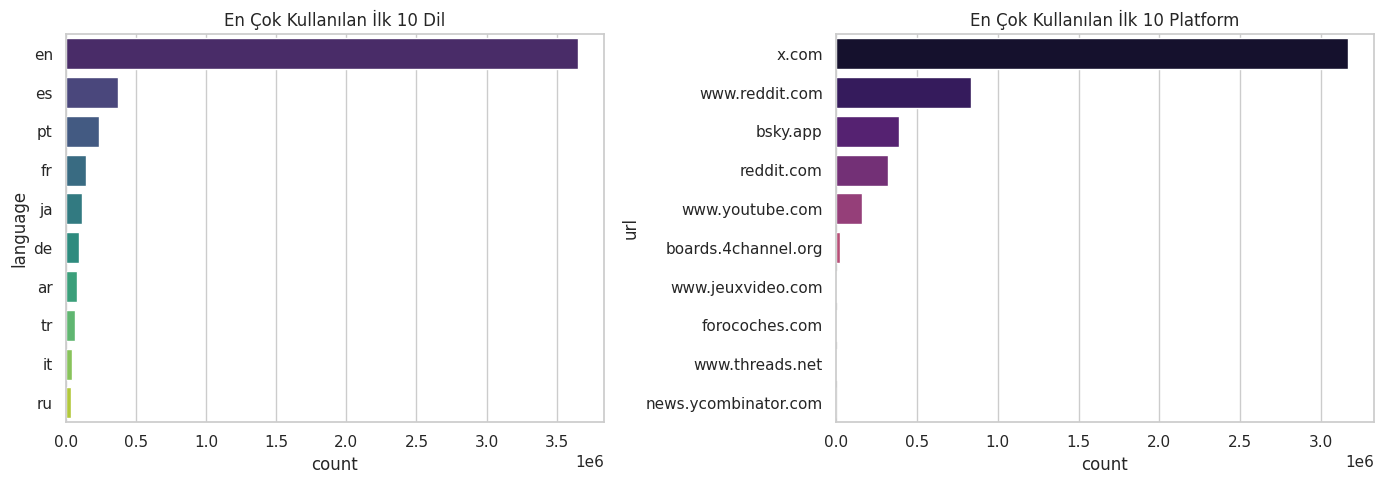

In [ ]:
# Dil ve URL Dağılımını hesapla
lang_dist = df_lazy.group_by("language").count().sort("count", descending=True).collect()
url_dist = df_lazy.group_by("url").count().sort("count", descending=True).collect()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dil Dağılımı (İlk 10)
sns.barplot(data=lang_dist.head(10).to_pandas(), x="count", y="language", ax=axes[0], palette="viridis")
axes[0].set_title("En Çok Kullanılan İlk 10 Dil")

# URL/Platform Dağılımı (İlk 10)
sns.barplot(data=url_dist.head(10).to_pandas(), x="count", y="url", ax=axes[1], palette="magma")
axes[1].set_title("En Çok Kullanılan İlk 10 Platform")

plt.tight_layout()
plt.show()

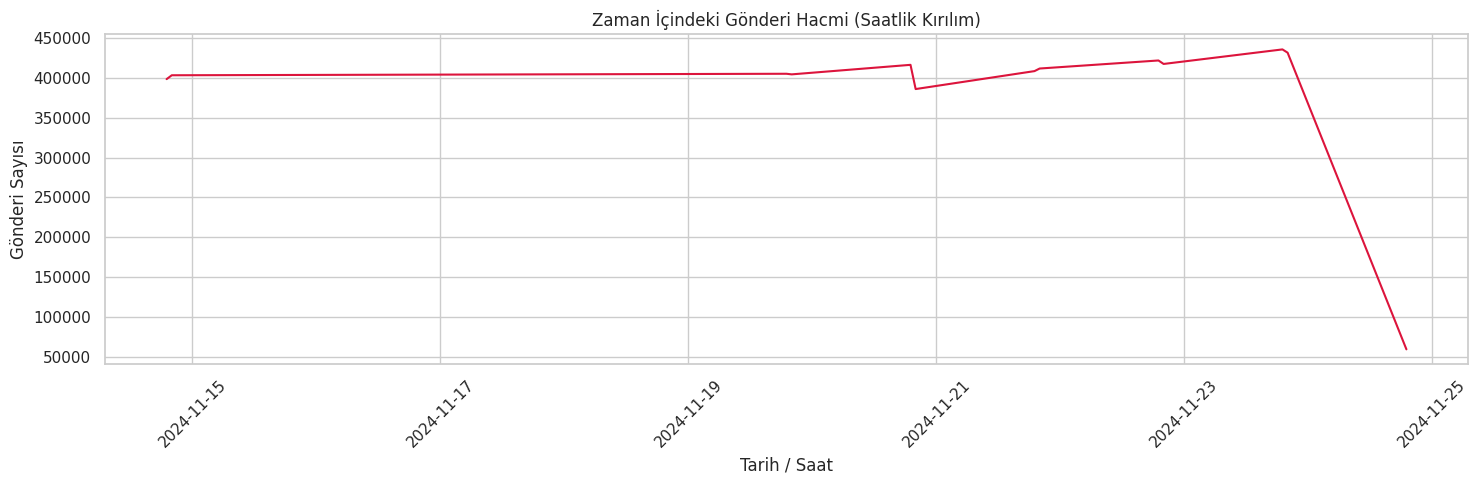

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

time_series = (
    df_lazy
    # 1. ADIM: "T" harfi varsa (ISO formatı) boşlukla değiştir.
    .with_columns(pl.col("date").str.replace("T", " "))

    # 2. ADIM: Sadece ilk 19 karakteri al (Örn: "2023-10-25 14:30:00") ve timezone'u çöpe at.
    # strict=False vererek olası bozuk satırları null (boş) değere çevirip hata vermesini engelliyoruz.
    .with_columns(
        pl.col("date")
        .str.slice(0, 19)
        .str.to_datetime(format="%Y-%m-%d %H:%M:%S", strict=False)
    )

    # 3. ADIM: Saatlik yuvarlama ve sayma (Kalan kısım aynı)
    .with_columns(pl.col("date").dt.truncate("1h").alias("hour_bucket"))
    .group_by("hour_bucket")
    .len(name="count")
    .sort("hour_bucket")
    .collect()
    .to_pandas()
)

# Görselleştirme
plt.figure(figsize=(15, 5))
sns.lineplot(data=time_series, x="hour_bucket", y="count", color="crimson")
plt.title("Zaman İçindeki Gönderi Hacmi (Saatlik Kırılım)")
plt.xlabel("Tarih / Saat")
plt.ylabel("Gönderi Sayısı")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [2]:
!pip install hdbscan polars pyarrow lightgbm sentence-transformers -q

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import hdbscan

sns.set_theme(style='whitegrid', context='talk')
PARQUET_PATH = '/content/drive/MyDrive/Data League /user_profiles_final_v1.parquet'
print('Tüm kütüphaneler yüklendi ✅')

Tüm kütüphaneler yüklendi ✅


In [3]:
user_profiles= pd.read_parquet(PARQUET_PATH, engine='pyarrow')

In [4]:
# ============================================================
# HÜCRE 12 — ANOMALİ SKORU (IsolationForest)
# YENİ HÜCRE: Görevde istenen 0-1 organiklik skoru burada
#             üretiliyor. Orijinal notebook'ta bu adım yoktu.
# ============================================================
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

FEATURE_COLS = [
    'post_count', 'unique_platforms', 'unique_languages', 'unique_themes',
    'time_diff_mean', 'time_diff_std', 'time_diff_min',
    'sentiment_mean', 'sentiment_std', 'emotion_diversity',
    'posts_per_platform', 'is_hyperactive',
    'lexical_diversity', 'semantic_rigidity',
    'text_length_mean', 'text_length_std',
    'avg_keywords_per_post', 'unique_active_hours',
    'keyword_stuffing_index'
]

# Eksik kalabilecek sütunları sıfırla doldur
X = user_profiles[FEATURE_COLS].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("IsolationForest eğitiliyor...")
iso = IsolationForest(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_scaled)

# decision_function → negatif = anormal; 0-1 arası normalize et
raw_scores = iso.decision_function(X_scaled)
# Organiklik skoru: yüksek = organik, düşük = şüpheli
min_s, max_s = raw_scores.min(), raw_scores.max()
user_profiles['organicity_score'] = (
    (raw_scores - min_s) / (max_s - min_s + 1e-9)
)
user_profiles['label'] = iso.predict(X_scaled)  # 1=normal, -1=anomaly
user_profiles['is_manipulative'] = (
    user_profiles['label'] == -1
).astype(int)

n_manip = user_profiles['is_manipulative'].sum()
print(f"\nTespit edilen manipülatif hesap sayısı: {n_manip:,}")
print(f"Toplam hesap: {len(user_profiles):,}")
print(f"Manipülatif oran: {n_manip/len(user_profiles):.2%}")
print(user_profiles[['author_hash','organicity_score','is_manipulative']].head(10))

IsolationForest eğitiliyor...

Tespit edilen manipülatif hesap sayısı: 183,040
Toplam hesap: 1,597,838
Manipülatif oran: 11.46%
                                author_hash  organicity_score  is_manipulative
0                                                    0.044597                1
1  0000071a2918d838352862180b3f47e1ed53c332          0.834087                0
2  00001b81dde185e114611d47298c2d7687e0b3ca          0.924521                0
3  000029fda00230cf218ee77deaeda5fbed6d5078          0.964689                0
4  00002ca22b693dab7a87d949a96cde8fd51a3af5          0.917842                0
5  000033ca89f27643bfbf28b84b54d471717dfbac          0.944770                0
6  00004d3cabf9b98fa0b7e26e2c991774d670a923          0.980700                0
7  00004f80d145fd9f3c53530767c72158ad2acdbf          0.988813                0
8  000051028e537a2ac7f1ccab6122318be5a48bb9          0.912376                0
9  000067f54d9b36e5ec2149761bfb2298ebbfd810          0.989838                0


Isolation Forest - Log Scale Dağılım Grafiği (Düzeltilmiş) Çiziliyor...


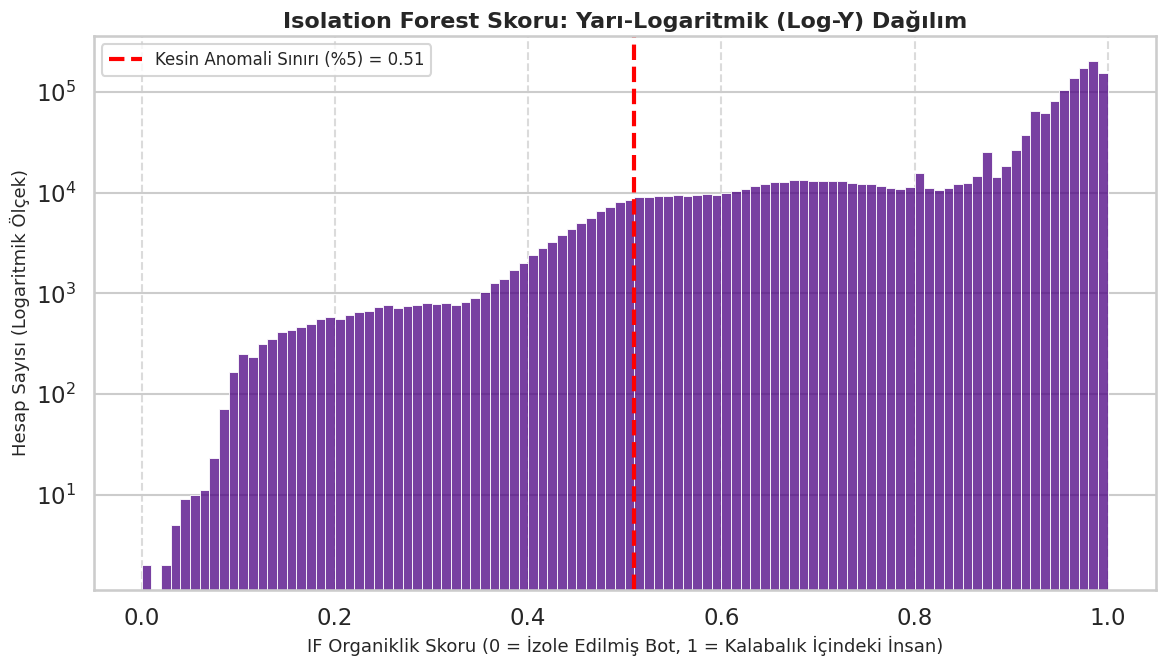

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Isolation Forest - Log Scale Dağılım Grafiği (Düzeltilmiş) Çiziliyor...")

plt.figure(figsize=(12, 7))

# BUG FİX: log_scale=(False, True) ve kde=True parametrelerini sildik.
# Önce standart histogramı çizdiriyoruz.
sns.histplot(user_profiles['organicity_score'], bins=100, color='indigo')

# SOTA DOKUNUŞU: Y eksenini sonradan güvenli bir şekilde logaritmik yapıyoruz.
plt.yscale('log')

# Kesin Anomali Sınırımız (%5)
threshold_5 = user_profiles['organicity_score'].quantile(0.05)
plt.axvline(threshold_5, color='red', linestyle='--', linewidth=3, label=f'Kesin Anomali Sınırı (%5) = {threshold_5:.2f}')

plt.title('Isolation Forest Skoru: Yarı-Logaritmik (Log-Y) Dağılım', fontsize=16, fontweight='bold')
plt.xlabel('IF Organiklik Skoru (0 = İzole Edilmiş Bot, 1 = Kalabalık İçindeki İnsan)', fontsize=13)
plt.ylabel('Hesap Sayısı (Logaritmik Ölçek)', fontsize=13)
plt.legend(fontsize=12)

# Okunabilirliği artırmak için dikey ızgara çizgileri
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd
import numpy as np
import torch
from sentence_transformers import CrossEncoder

# 1. GPU KONTROLÜ
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Kullanılan İşlemci: {device.upper()}")
if device == 'cpu':
    print("UYARI: GPU aktif değil! Lütfen Colab ayarlarından T4 GPU'yu seçin.")

# 2. MODELİ GPU'YA YÜKLEME
print("Model GPU belleğine yükleniyor...")
# device=device parametresi modelin doğrudan VRAM'e (Ekran Kartı Belleği) inmesini sağlar
embed_model = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', device=device)

Kullanılan İşlemci: CUDA
Model GPU belleğine yükleniyor...


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [18]:
# ============================================================
# TAHMİN FONKSİYONU — SADECE PLAIN TEXT
# ============================================================
import regex as re
IF_SCORE_MIN      = -0.20
IF_SCORE_MAX      =  0.05
OPTIMAL_THRESHOLD =  0.87
EMBEDDING_WEIGHT  =  0.6
def predict(text: str, verbose: bool = True) -> dict:

    text  = str(text).strip()
    words = text.split()
    n     = len(words)
    chars = len(text)

    # ── METİN SİNYALLERİ ───────────────────────────────────
    unique_ratio  = len(set(w.lower() for w in words)) / (n + 1)
    upper_ratio   = sum(1 for c in text if c.isupper()) / (chars + 1)
    hashtags      = re.findall(r'#\w+', text)
    mentions      = re.findall(r'@\w+', text)
    urls          = re.findall(r'http\S+', text)
    emojis        = re.findall(u'[\U0001F600-\U0001F9FF]', text, re.UNICODE)
    punct_repeat  = len(re.findall(r'[!?]{2,}', text))
    special_den   = (len(hashtags)+len(mentions)+len(urls)+len(emojis)) / (n+1)



    # ── TABULAR SATIR ──────────────────────────────────────
    row = {col: 0.0 for col in FEATURE_COLS}
    row['text_length_mean']        = chars
    row['text_length_std']         = 0.0
    row['lexical_diversity']       = unique_ratio
    row['keyword_stuffing_index']  = special_den * 10
    row['post_count']              = 1
    row['posts_per_platform']      = 1
    row['unique_platforms']        = 1
    row['unique_languages']        = 1
    row['unique_themes']           = 1
    row['sentiment_mean']          = 0.0
    row['sentiment_std']           = 0.0
    row['emotion_diversity']       = 1

    tab = scaler_tab.transform(
        pd.DataFrame([row])[FEATURE_COLS].fillna(0)
    )



    # ── KARAR ──────────────────────────────────────────────
    is_manip = score < OPTIMAL_THRESHOLD
    gap      = abs(score - OPTIMAL_THRESHOLD)
    guven    = 'YÜKSEK' if gap > 0.25 else 'ORTA' if gap > 0.10 else 'GRİ ALAN'
    karar    = '🔴 MANİPÜLATİF' if is_manip else '🟢 ORGANİK'

    # ── AÇIKLAMALAR ────────────────────────────────────────
    flags = []
    if chars < 15:
        flags.append(f'📏 Çok kısa metin ({chars} karakter)')
    if unique_ratio < 0.5:
        flags.append(f'🔁 Kelime tekrarı yüksek ({unique_ratio:.0%} benzersiz)')
    if upper_ratio > 0.4:
        flags.append(f'🔠 Aşırı büyük harf (%{upper_ratio*100:.0f})')
    if len(hashtags) >= 3:
        flags.append(f'#️⃣  Yoğun hashtag ({len(hashtags)}): {" ".join(hashtags[:5])}')
    if punct_repeat >= 2:
        flags.append(f'❗ Noktalama tekrarı ({punct_repeat} kez)')
    if special_den > 0.3:
        flags.append(f'⚠️  Yüksek özel karakter yoğunluğu ({special_den:.2f})')
    if urls:
        flags.append(f'🔗 {len(urls)} URL tespit edildi')
    if not flags:
        flags.append('✅ Şüpheli sinyal tespit edilmedi')

    result = {
        'karar'  : karar,
        'skor'   : round(score, 4),
        'esik'   : OPTIMAL_THRESHOLD,
        'guven'  : guven,
        'flags'  : flags,
    }

    if verbose:
        print('━' * 58)
        print(f'  📝 "{text[:55]}{"..." if chars>55 else ""}"')
        print('━' * 58)
        print(f'  Karar   : {karar}')
        print(f'  Skor    : {score:.4f}   (eşik={OPTIMAL_THRESHOLD})')
        print(f'  Güven   : {guven}')
        print(f'  Sinyaller:')
        for f in flags:
            print(f'    {f}')
        print('━' * 58)

    return result

In [10]:
# ============================================================
# TOPLU TEST — juri_test()
# ============================================================
def juri_test(texts: list) -> pd.DataFrame:

    print('\n' + '▓' * 58)
    print('      JÜRİ SUNUM MODU — PLAIN TEXT TEST')
    print('▓' * 58)

    rows = []
    for i, text in enumerate(texts, 1):
        print(f'\n── [{i}/{len(texts)}] ──')
        r = predict(text, verbose=True)
        rows.append({
            'metin'  : text[:50] + ('...' if len(text)>50 else ''),
            'skor'   : r['skor'],
            'karar'  : r['karar'],
            'guven'  : r['guven'],
            'sinyal' : ' | '.join(r['flags'])
        })

    df = pd.DataFrame(rows)

    print('\n' + '=' * 58)
    print('  ÖZET TABLO')
    print('=' * 58)
    for _, row in df.iterrows():
        print(f"  {row['skor']:.4f}  {row['karar']}  [{row['guven']}]")
        print(f"  📝 {row['metin']}")
        print()

    n_manip = (df['karar'].str.contains('🔴')).sum()
    n_org   = len(df) - n_manip
    print('=' * 58)
    print(f'  Toplam  : {len(df)} metin')
    print(f'  🔴 Manipülatif : {n_manip}')
    print(f'  🟢 Organik     : {n_org}')
    print('=' * 58)

    return df

In [20]:
# ============================================================
# ÇALIŞTIR — metinleri buraya yaz
# ============================================================
sonuclar = juri_test([

    # — organik —
    "Bugün işten çok yorgun döndüm, çocuklar uyumuştu bile.",
    "Hava güzeldi, öğleden sonra kısa bir yürüyüş yaptım.",
    "The new coffee shop near my office is actually pretty good.",
    "Dün izlediğim film beklediğim kadar iyi değildi açıkçası.",

    # — manipülatif —
    "Bu hükümet halkı mahvediyor!!! Sokaklara çıkın! #direniş #devrim #yalan",
    "BUY $MOONTOKEN NOW!!! 1000x guaranteed 🚀🚀🚀 Don't miss!!",
    "BREAKING: vaccines cause autism. MSM hiding truth. WAKE UP SHEEPLE!!!",
    "El gobierno nos miente!!! #resistencia #verdad #libertad #revolución",

    # — gri alan —
    "I've been using this supplement for 3 months and honestly it works.",
    "As a nurse I've seen firsthand how this policy is harming patients.",
])


▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
      JÜRİ SUNUM MODU — PLAIN TEXT TEST
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

── [1/10] ──


NameError: name 'scaler_tab' is not defined

1. Manipülatif Hesaplar Orijinal Veriyle Eşleştiriliyor...
Botlar tarafından atılan toplam şüpheli gönderi sayısı: 2,900,117

2. Dağılım Grafikleri Çiziliyor...


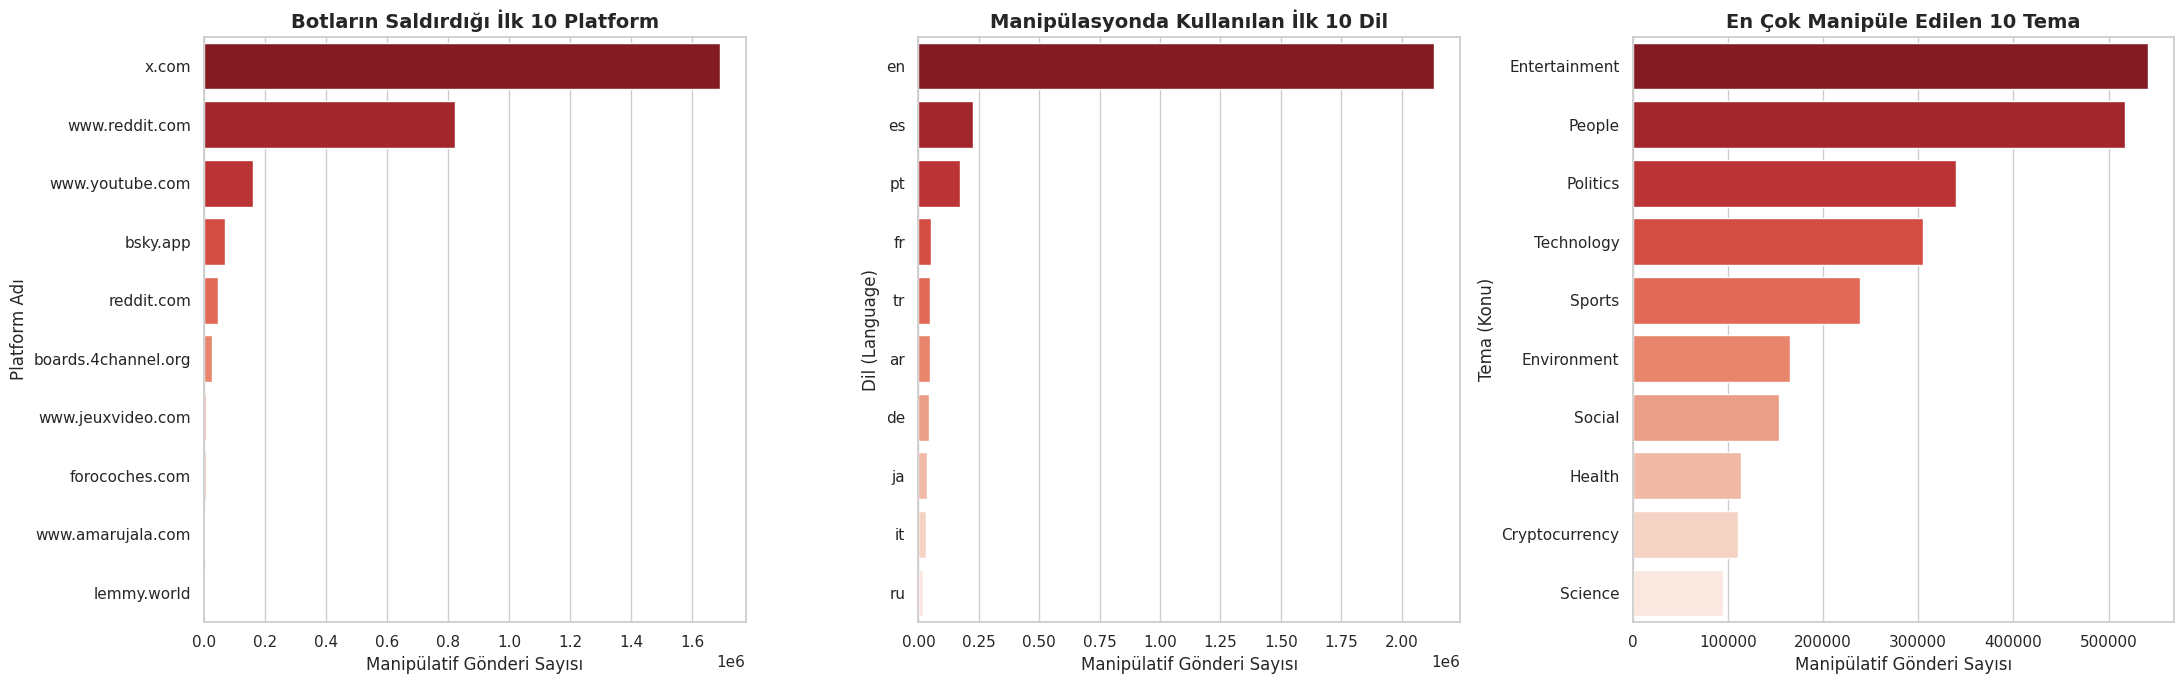

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

print("1. Manipülatif Hesaplar Orijinal Veriyle Eşleştiriliyor...")

# Önceki adımdaki %5'lik eşiğimizi (threshold_5) kullanarak botların yazar ID'lerini (author_hash) alıyoruz
manipulative_hashes = user_profiles[user_profiles['organicity_score'] <= threshold_5]['author_hash']

# Orijinal ham verimiz (df) üzerinden sadece botların attığı gönderileri filtreliyoruz
# NOT: Eğer ham verinin adı 'df' değilse (örn: 'data', 'tweets'), aşağıdaki 'df' kelimelerini değiştir.
df_bots = df[df['author_hash'].isin(manipulative_hashes)]

print(f"Botlar tarafından atılan toplam şüpheli gönderi sayısı: {len(df_bots):,}")
print("\n2. Dağılım Grafikleri Çiziliyor...")

# Şık ve profesyonel bir sunum için 3'lü yan yana grafik düzeni
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# SOTA Renk Paleti: Botların tehlikesini vurgulamak için Koyu Kırmızıdan açığa doğru (Reds_r)

# --- 1. PLATFORM DAĞILIMI ---
# Botlar en çok hangi platformlara saldırıyor? (İlk 10 Platform)
sns.countplot(y='url', data=df_bots,
              order=df_bots['url'].value_counts().index[:10],
              palette='Reds_r', ax=axes[0])
axes[0].set_title('Botların Saldırdığı İlk 10 Platform', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Manipülatif Gönderi Sayısı')
axes[0].set_ylabel('Platform Adı')

# --- 2. DİL DAĞILIMI ---
# Bot ağları en çok hangi dilde propaganda yapıyor? (İlk 10 Dil)
sns.countplot(y='language', data=df_bots,
              order=df_bots['language'].value_counts().index[:10],
              palette='Reds_r', ax=axes[1])
axes[1].set_title('Manipülasyonda Kullanılan İlk 10 Dil', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Manipülatif Gönderi Sayısı')
axes[1].set_ylabel('Dil (Language)')

# --- 3. TEMA (KONU) DAĞILIMI ---
# Botlar gündemde hangi konuları (Tema) şişiriyor? (İlk 10 Tema)
# Eğer temanın sütun adı farklıysa 'theme' kısmını değiştir (Örn: 'topic', 'category')
sns.countplot(y='primary_theme', data=df_bots,
              order=df_bots['primary_theme'].value_counts().index[:10],
              palette='Reds_r', ax=axes[2])
axes[2].set_title('En Çok Manipüle Edilen 10 Tema', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Manipülatif Gönderi Sayısı')
axes[2].set_ylabel('Tema (Konu)')

# Grafikleri estetik olarak sıkıştır ve göster
plt.tight_layout()
plt.show()

Isolation Forest (Unsupervised) Sonuçları Görselleştiriliyor...


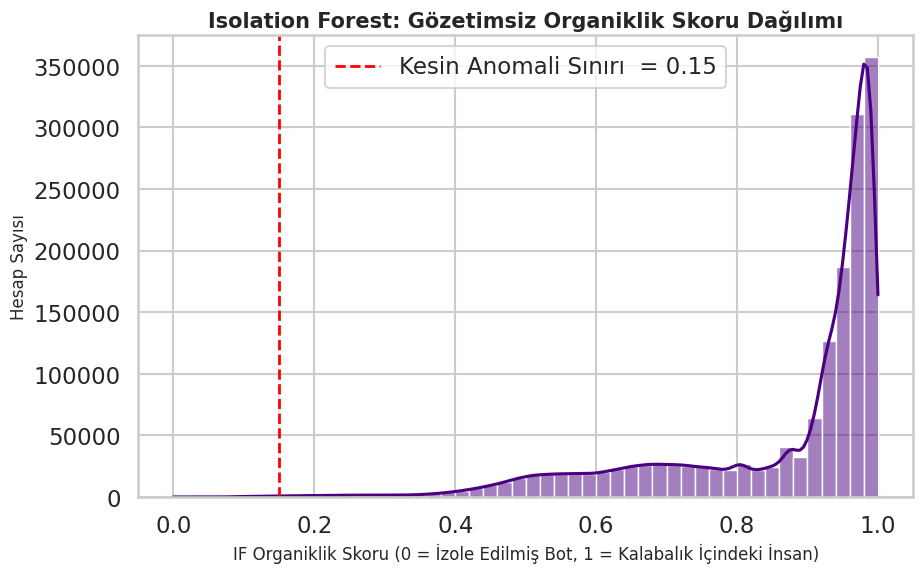

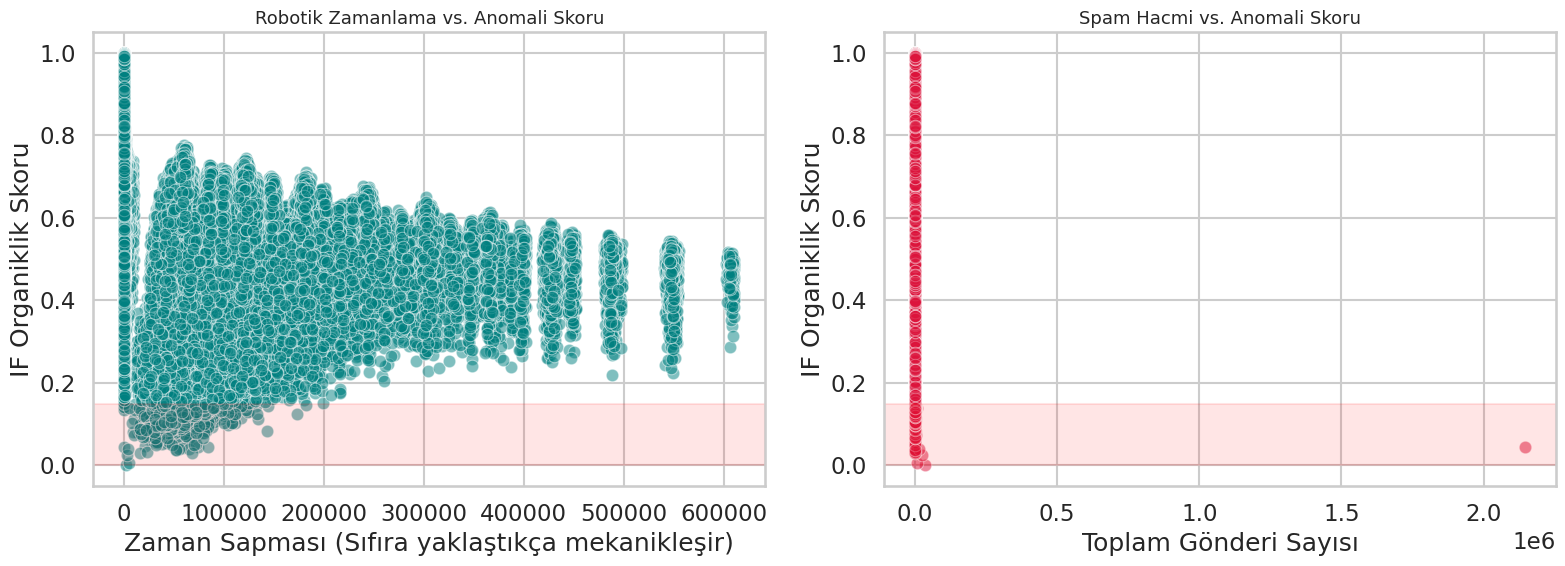

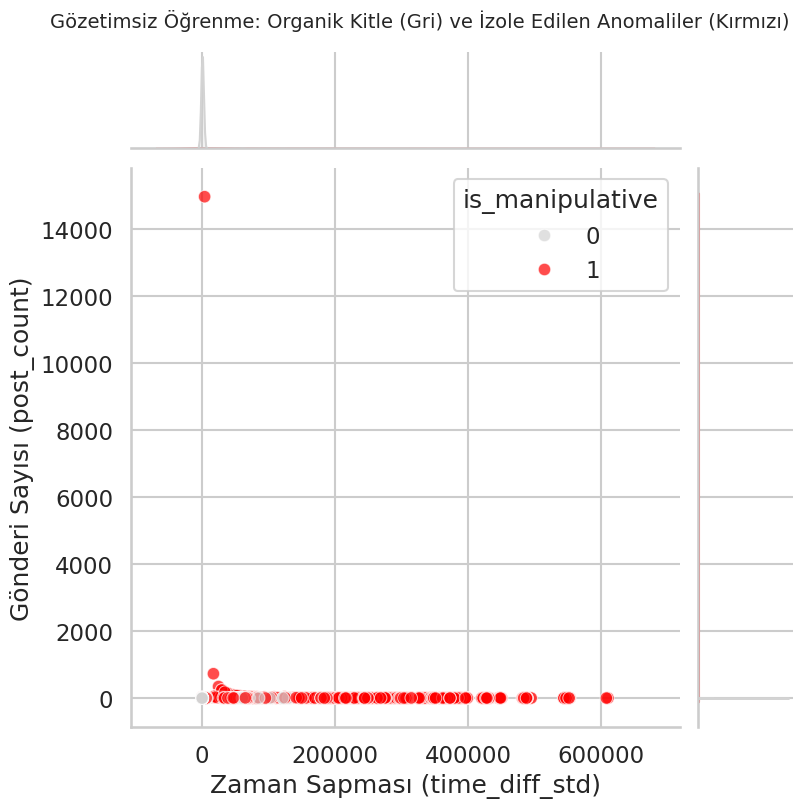

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Isolation Forest (Unsupervised) Sonuçları Görselleştiriliyor...")

# 1. GRAFİK: ANOMALİ SKORU DAĞILIMI (HISTOGRAM)
# İzolasyon ormanı kitleyi nasıl ikiye böldü?
plt.figure(figsize=(10, 6))
# Hücre 12'de ürettiğimiz saf IF skorunu kullanıyoruz
sns.histplot(user_profiles['organicity_score'], bins=50, kde=True, color='indigo')

# En şüpheli %5'lik anomali sınırımızı kırmızı çizgiyle çekiyoruz
threshold_5 = user_profiles['organicity_score'].quantile(n_manip/(len(user_profiles)*100))
plt.axvline(threshold_5, color='red', linestyle='--', linewidth=2, label=f'Kesin Anomali Sınırı  = {threshold_5:.2f}')

plt.title('Isolation Forest: Gözetimsiz Organiklik Skoru Dağılımı', fontsize=15, fontweight='bold')
plt.xlabel('IF Organiklik Skoru (0 = İzole Edilmiş Bot, 1 = Kalabalık İçindeki İnsan)', fontsize=12)
plt.ylabel('Hesap Sayısı', fontsize=12)
plt.legend()
plt.show()

# 2. GRAFİK: BOTLARIN RÖNTGENİ (SCATTER PLOT)
# Orman bu hesapları neye göre 'Anormal' bulup sıfıra itti?
# En kritik 2 davranışsal özelliğimizi seçelim: 'time_diff_std' ve 'post_count'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol Grafik: Zaman Mekanikliği (Robotik hız)
sns.scatterplot(data=user_profiles, x='time_diff_std', y='organicity_score',
                alpha=0.5, color='teal', ax=axes[0])
axes[0].set_title('Robotik Zamanlama vs. Anomali Skoru', fontsize=13)
axes[0].set_xlabel('Zaman Sapması (Sıfıra yaklaştıkça mekanikleşir)')
axes[0].set_ylabel('IF Organiklik Skoru')
# Anomali bölgesini tarayalım
axes[0].axhspan(0, threshold_5, color='red', alpha=0.1)

# Sağ Grafik: Gönderi Hacmi (Spam)
sns.scatterplot(data=user_profiles, x='post_count', y='organicity_score',
                alpha=0.5, color='crimson', ax=axes[1])
axes[1].set_title('Spam Hacmi vs. Anomali Skoru', fontsize=13)
axes[1].set_xlabel('Toplam Gönderi Sayısı')
axes[1].set_ylabel('IF Organiklik Skoru')
axes[1].axhspan(0, threshold_5, color='red', alpha=0.1)

plt.tight_layout()
plt.show()

# 3. GRAFİK: DAVRANIŞSAL UZAYDA İZOLASYON (JOINTPLOT)
# İnsanlar nerede kümeleniyor, Botlar nereye izole oluyor?
# (Hızlı çalışması için rastgele 50 bin örneklem (sample) alıyoruz)
sample_df = user_profiles.sample(50000, random_state=42)

g = sns.jointplot(data=sample_df, x='time_diff_std', y='post_count',
                  hue='is_manipulative', palette={0: 'lightgray', 1: 'red'},
                  alpha=0.7, height=8)
g.fig.suptitle('Gözetimsiz Öğrenme: Organik Kitle (Gri) ve İzole Edilen Anomaliler (Kırmızı)', y=1.02, fontsize=14)
g.set_axis_labels('Zaman Sapması (time_diff_std)', 'Gönderi Sayısı (post_count)')
plt.show()

In [79]:
import os
save_path = '/content/drive/MyDrive/Data League /'
file_name = "user_profiles_final_v1.parquet"
full_file_path = os.path.join(save_path, file_name)

user_profiles.to_parquet(full_file_path, index=False)

print(f"✅ İşlem Tamam! Veritabanı buraya kaydedildi: {full_file_path}")

✅ İşlem Tamam! Veritabanı buraya kaydedildi: /content/drive/MyDrive/Data League /user_profiles_final_v1.parquet


1. Gri Alan (Eğitim Dışı) Verisi Ayrıştırılıyor...
Gri Alan Test Seti Büyüklüğü: 1,278,269 hesap

2. Gri Alan Olasılık Dağılımı (Probability Distribution) Çiziliyor...


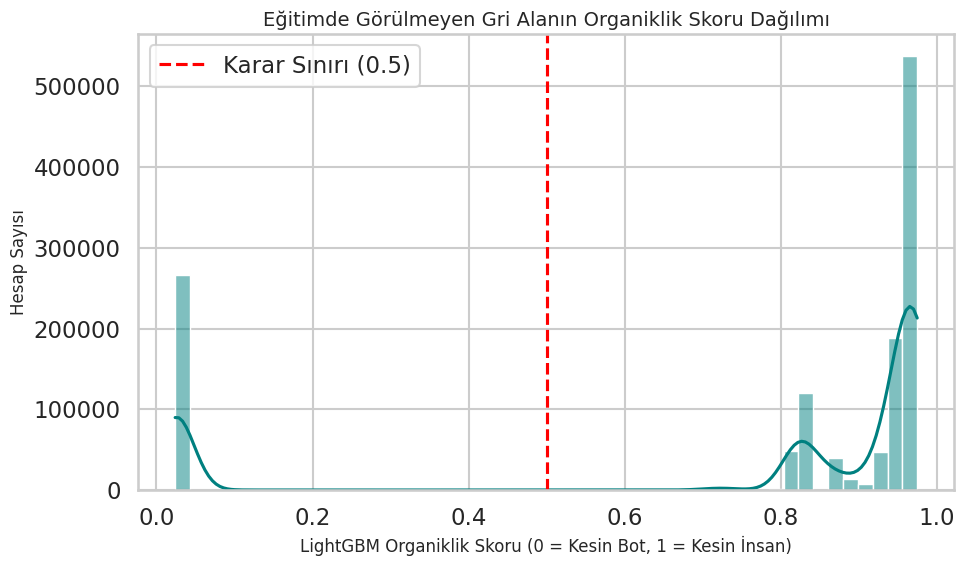


3. Gri Alandan 'Kör Test' (Sanity Check) Örnekleri...

--- GRİ ALANIN EN 'ŞÜPHELİ' 5 HESABI (Modelin Bot Dedikleri) ---
                                      author_hash  post_count  time_diff_std  \
995257   9f940882f435651f904d429d95f473f9787b0b0c           2           -1.0   
1193310  bf2f8e2221952cdd4bd8b66715c8203f881423a0           2           -1.0   
1026452  a48ac3b30f93f6a3d41b6a669bfe887c8befbdd5           2           -1.0   
941532   96fdc6c47ce0c2b42945556906a9ad20421f4fa5           2           -1.0   
101079   1032cd21f03cdc541f8865ab0b255d81d4d1beff           2           -1.0   

         semantic_rigidity  avg_campaign_uniqueness  final_organic_score  
995257                -1.0                 0.993892              0.02397  
1193310               -1.0                 0.991834              0.02397  
1026452               -1.0                 0.992188              0.02397  
941532                -1.0                 0.993892              0.02397  
101079                -

In [ ]:
# ============================================================
# HÜCRE 14 — GRİ ALAN (GREY AREA) VALİDASYONU VE ANALİZİ
# Modelin eğitimde hiç görmediği, etiketsiz yığın üzerindeki performansı
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("1. Gri Alan (Eğitim Dışı) Verisi Ayrıştırılıyor...")
# pseudo_label_lgbm sütunu NaN olanlar, eğitimde kullanmadığımız o devasa gri kitledir
grey_area_mask = user_profiles['pseudo_label_lgbm'].isna()
df_grey = user_profiles[grey_area_mask].copy()

print(f"Gri Alan Test Seti Büyüklüğü: {len(df_grey):,} hesap")

print("\n2. Gri Alan Olasılık Dağılımı (Probability Distribution) Çiziliyor...")
# SOTA Validasyonu: Eğer bu grafik sadece 0 ve 1'de iki devasa sütun gösteriyorsa overfit vardır.
# Eğer 0.2, 0.5, 0.8 gibi noktalara yayılmış bir çan eğrisi veya tepecikler varsa model gerçeği öğrenmiştir.
plt.figure(figsize=(10, 6))
sns.histplot(df_grey['final_organic_score'], bins=50, color='teal', kde=True)
plt.title('Eğitimde Görülmeyen Gri Alanın Organiklik Skoru Dağılımı', fontsize=14)
plt.xlabel('LightGBM Organiklik Skoru (0 = Kesin Bot, 1 = Kesin İnsan)', fontsize=12)
plt.ylabel('Hesap Sayısı', fontsize=12)
plt.axvline(x=0.5, color='red', linestyle='--', label='Karar Sınırı (0.5)')
plt.legend()
plt.tight_layout()
plt.show()

print("\n3. Gri Alandan 'Kör Test' (Sanity Check) Örnekleri...")
# En Kritik Analiz: Model gri alanda kime 'Bot' kime 'İnsan' dedi? Mantıklı mı?

# Özellikleri jüriye göstermek için kritik sütunları seçiyoruz
check_cols = ['author_hash', 'post_count', 'time_diff_std', 'semantic_rigidity', 'avg_campaign_uniqueness', 'final_organic_score']

print("\n--- GRİ ALANIN EN 'ŞÜPHELİ' 5 HESABI (Modelin Bot Dedikleri) ---")
# Skoru sıfıra en yakın olanlar (Ascending=True)
print(df_grey.sort_values('final_organic_score')[check_cols].head(5))

print("\n--- GRİ ALANIN EN 'TEMİZ' 5 HESABI (Modelin İnsan Dedikleri) ---")
# Skoru bire en yakın olanlar (Ascending=False)
print(df_grey.sort_values('final_organic_score', ascending=False)[check_cols].head(5))

print("\n--- GRİ ALANIN TAM ORTASINDAKİ 5 HESAP (Modelin Kararsız Kaldıkları) ---")
# Skoru 0.50 civarında olanlar (Gerçek gri hesaplar)
df_grey['distance_to_center'] = abs(df_grey['final_organic_score'] - 0.5)
print(df_grey.sort_values('distance_to_center')[check_cols].head(5))

Unsupervised Kümeleme Başlatılıyor...


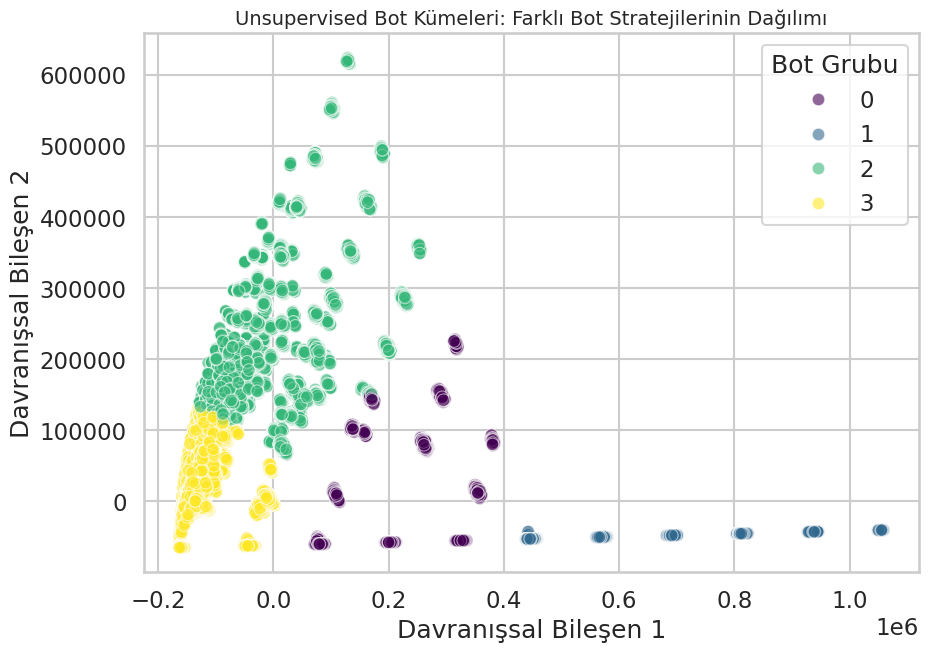

In [ ]:
# ============================================================
# HÜCRE 15 — UNSUPERVISED CLUSTERING (Bot Gruplarını Bulma)
# Modelin 'Bot' dediği hesaplar gerçekten birbirine benziyor mu?
# ============================================================
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

print("Unsupervised Kümeleme Başlatılıyor...")

# 1. Sadece modelin 'Şüpheli' (Düşük organiklik skoru) bulduğu hesapları alalım
suspicious_users = user_profiles[user_profiles['final_organic_score'] < 0.3].copy()

# 2. Bu hesapları davranışsal benzerliklerine göre 4 ana gruba ayıralım
# (Örn: Hızlı botlar, Spamcı botlar, Taklitçi botlar vb.)
kmeans = KMeans(n_clusters=4, random_state=42)
suspicious_users['bot_cluster'] = kmeans.fit_predict(suspicious_users[FEATURE_COLS].fillna(0))

# 3. Görselleştirme için 19 boyutu (Feature sayısı) 2 boyuta indirelim (PCA)
pca = PCA(n_components=2)
components = pca.fit_transform(suspicious_users[FEATURE_COLS].fillna(0))

plt.figure(figsize=(10, 7))
sns.scatterplot(x=components[:, 0], y=components[:, 1], hue=suspicious_users['bot_cluster'], palette='viridis', alpha=0.6)
plt.title('Unsupervised Bot Kümeleri: Farklı Bot Stratejilerinin Dağılımı', fontsize=14)
plt.xlabel('Davranışsal Bileşen 1')
plt.ylabel('Davranışsal Bileşen 2')
plt.legend(title='Bot Grubu')
plt.show()

Modelin Test Seti Üzerindeki Karmaşıklık Matrisi Çiziliyor...


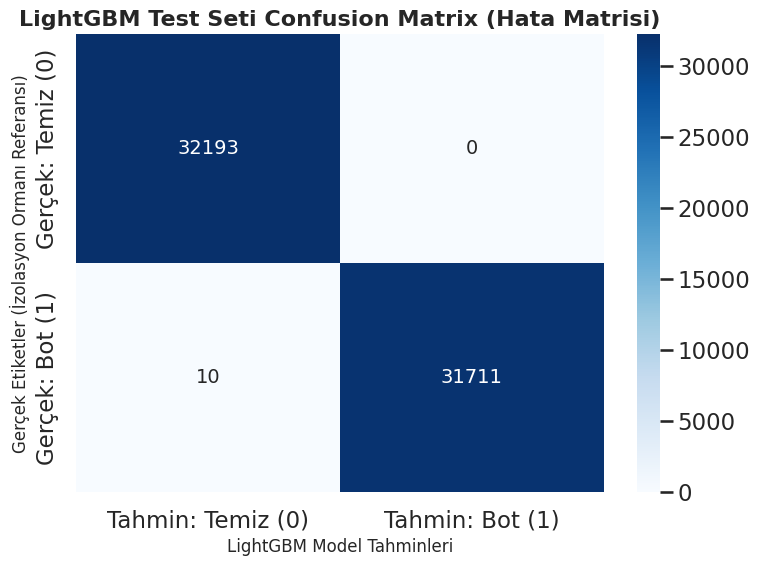


--- MATRİSİN ANLAM KILAVUZU ---
✅ True Negative (TN) - Doğru İnsan Tespiti: 32,193 (Gerçekten temizdi, model de temiz dedi)
✅ True Positive (TP) - Doğru Bot Tespiti: 31,711 (Gerçekten bot tu, model de bot dedi)
❌ False Positive (FP) - Masuma İftira (Tip 1 Hata): 0 (İnsandı, ama model yanlışlıkla bot dedi)
❌ False Negative (FN) - Kaçan Botlar (Tip 2 Hata): 10 (Bottu, ama model gözden kaçırıp temiz dedi)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Modelin Test Seti Üzerindeki Karmaşıklık Matrisi Çiziliyor...")

# y_test ve y_pred değişkenleri, bir önceki (Hücre 13) LightGBM model eğitiminden geliyor.
# Hatırlatma: 0 = Temiz İnsan, 1 = Manipülatif Bot
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
# fmt='d' ile sayıların ondalıklı (scientific) değil, tam sayı görünmesini sağlıyoruz
# cmap='Blues' sunumlar için en temiz ve profesyonel renk paletidir
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 14},
            xticklabels=['Tahmin: Temiz (0)', 'Tahmin: Bot (1)'],
            yticklabels=['Gerçek: Temiz (0)', 'Gerçek: Bot (1)'])

plt.title('LightGBM Test Seti Confusion Matrix (Hata Matrisi)', fontsize=16, fontweight='bold')
plt.ylabel('Gerçek Etiketler (İzolasyon Ormanı Referansı)', fontsize=12)
plt.xlabel('LightGBM Model Tahminleri', fontsize=12)
plt.tight_layout()
plt.show()

# --- MATRİSİN OKUNMASI (Jüriye Açıklama Notları) ---
tn, fp, fn, tp = cm.ravel()
print("\n--- MATRİSİN ANLAM KILAVUZU ---")
print(f"✅ True Negative (TN) - Doğru İnsan Tespiti: {tn:,} (Gerçekten temizdi, model de temiz dedi)")
print(f"✅ True Positive (TP) - Doğru Bot Tespiti: {tp:,} (Gerçekten bot tu, model de bot dedi)")
print(f"❌ False Positive (FP) - Masuma İftira (Tip 1 Hata): {fp:,} (İnsandı, ama model yanlışlıkla bot dedi)")
print(f"❌ False Negative (FN) - Kaçan Botlar (Tip 2 Hata): {fn:,} (Bottu, ama model gözden kaçırıp temiz dedi)")

Spearman Özellik Korelasyon Matrisi Hesaplanıyor... (Bu birkaç saniye sürebilir)


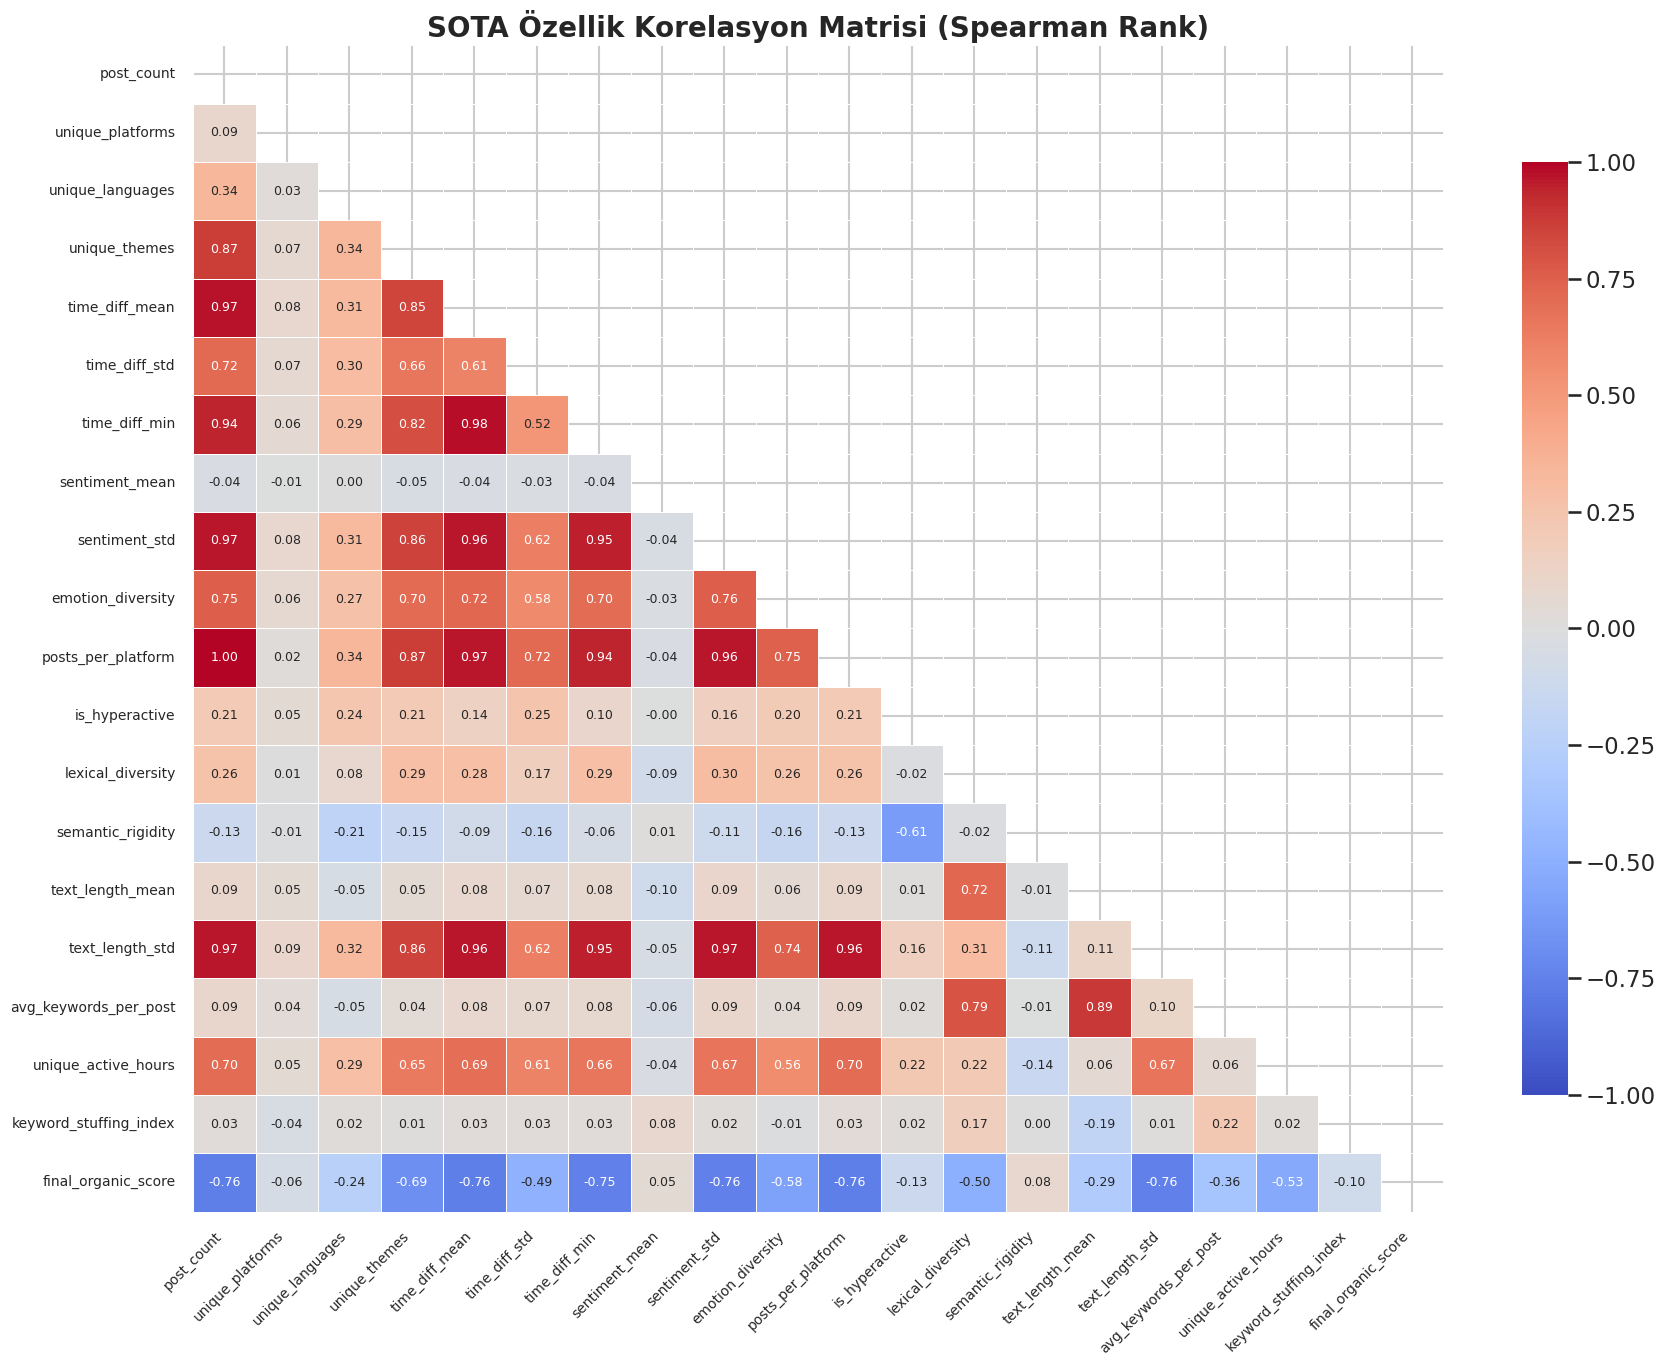

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Spearman Özellik Korelasyon Matrisi Hesaplanıyor... (Bu birkaç saniye sürebilir)")

# 1. Korelasyona sokulacak sütunları seçelim
# Orijinal özelliklerimiz ve modelin ürettiği hedef olasılık skorunu alıyoruz
cols_to_correlate = FEATURE_COLS + ['final_organic_score']

# 2. NaN değerleri korelasyon matematiğini bozmaması için sıfır ile dolduruyoruz
# method='spearman' outlier'lara (aşırı uçlara) karşı çok daha dirençlidir.
corr_matrix = user_profiles[cols_to_correlate].fillna(0).corr(method='spearman')

# 3. Profesyonel Görünüm: Matrisin üst yarısı kendini tekrar ettiği için maskeleyip gizliyoruz
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Görselleştirme (Heatmap)
plt.figure(figsize=(18, 14))

# cmap='coolwarm' SOTA bir seçimdir.
# Kırmızı = Aynı yönde hareket edenler (Pozitif)
# Mavi = Zıt yönde hareket edenler (Negatif)
sns.heatmap(corr_matrix,
            mask=mask,
            cmap='coolwarm',
            vmin=-1, vmax=1,
            center=0,
            annot=True,          # Sayıları göster
            fmt=".2f",           # Virgülden sonra 2 hane
            annot_kws={"size": 9},
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title('SOTA Özellik Korelasyon Matrisi (Spearman Rank)', fontsize=20, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()